In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score,classification_report,auc

<h2>Import the Dataset</h2>

In [67]:
df=pd.read_csv("./Data/train_data.csv")
df.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [68]:
y_train=df['class']
X=df.drop(labels="class",axis=1)
X.head()


,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [69]:
y_train.value_counts()

0    40
1    40
2    40
Name: class, dtype: int64

In [70]:
scaler=StandardScaler()
cols=X.columns
X_train=pd.DataFrame(scaler.fit_transform(X),columns=cols)
X_train.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.103789,1.135458,-0.068860,-0.068860,0.631463,1.188720,0.744575,-0.417389,0.552925,-0.584817,...,0.126660,0.142939,0.086579,0.511936,1.135458,0.831089,0.829870,0.635882,-0.686903,-1.076539
1,-0.680372,-0.096930,-0.590980,-0.590980,0.288586,0.518011,-0.536722,0.727370,-0.678133,0.647681,...,-0.672298,-0.704388,-0.627683,-0.687257,-0.096930,-0.518169,0.648174,-0.583856,0.581419,0.209637
2,0.520681,2.596747,-0.363470,-0.363470,1.326454,1.804441,1.322993,-0.624613,0.800081,-0.909542,...,0.569488,0.496156,0.599601,0.731857,2.596747,1.210846,1.449196,0.662878,-1.158663,-2.304490
3,-0.899305,-0.586223,-1.603131,-1.603131,-1.113906,-0.796778,-0.746084,0.868106,-0.859438,0.786830,...,-0.898848,-0.883758,-0.926553,-0.873852,-0.586223,-0.731061,0.969384,-0.959816,0.758550,0.606726
4,0.055406,1.564583,-0.151808,-0.151808,1.947260,2.430295,0.515526,0.013004,0.099613,-0.181000,...,0.088959,-0.017247,0.234410,0.072233,1.564583,0.507380,1.043203,0.242510,-0.384961,-1.338453


In [71]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Autocorrelation                       120 non-null    float64
 1   Contrast                              120 non-null    float64
 2   Correlation                           120 non-null    float64
 3   Correlation.1                         120 non-null    float64
 4   Cluster Prominence                    120 non-null    float64
 5   Cluster Shade                         120 non-null    float64
 6   Dissimilarity                         120 non-null    float64
 7   Energy                                120 non-null    float64
 8   Entropy                               120 non-null    float64
 9    Homogeneity                          120 non-null    float64
 10  Homogeneity: [2]                      120 non-null    float64
 11  Maximum probability

In [72]:
X_train.describe().apply(lambda s:s.apply("{0:.5f}".format))

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
count,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,...,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000,120.00000
mean,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,...,-0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000
std,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,...,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419,1.00419
min,-1.10782,-1.71325,-3.25142,-3.25142,-1.85066,-1.88742,-1.45906,-1.63607,-1.39430,-1.92654,...,-1.12825,-1.11484,-1.14304,-1.38843,-1.71325,-1.66166,-2.71528,-2.16523,-1.95276,-2.30449
25%,-0.84141,-0.72594,-0.71643,-0.71643,-0.71068,-0.73506,-0.88587,-1.18085,-0.93072,-0.91649,...,-0.84597,-0.86967,-0.81486,-0.92665,-0.72594,-0.91464,-0.62578,-0.85113,-0.84385,-0.78033
50%,-0.49025,-0.03014,0.29667,0.29667,-0.12936,-0.17730,-0.20096,0.33584,-0.29086,0.27402,...,-0.47507,-0.48426,-0.46897,-0.30061,-0.03014,-0.05804,0.11575,0.01612,0.22050,0.04977
75%,0.94049,0.73300,0.74875,0.74875,0.63854,0.56298,0.82877,0.93264,1.03107,0.91376,...,0.92337,1.07730,0.81028,1.06398,0.73300,0.89910,0.73559,1.11472,0.89683,0.75780
max,2.52279,2.59675,1.59095,1.59095,3.58591,3.39018,1.95489,1.28409,1.78031,1.34333,...,2.49454,2.10580,3.11322,1.74849,2.59675,1.67822,2.55872,1.27789,1.41853,1.66159


<h2>Visualizing the dataset in two-dimensions using Principal Component Analysis</h2>

In [73]:
pca = PCA(n_components=2,copy=True)
transformed_train=pca.fit_transform(X_train)
transformed_train.shape

(120, 2)

In [74]:
columns=['feature 1','feature 2']
transformed_train=pd.DataFrame(transformed_train,columns=columns)
print(transformed_train.shape)
transformed_train.head()

(120, 2)


,feature 1,feature 2
0,2.367027,1.471626
1,-2.335051,1.045765
2,4.441997,3.019470
3,-3.702682,1.926080
4,1.813747,1.898813


<AxesSubplot:xlabel='feature 1', ylabel='feature 2'>

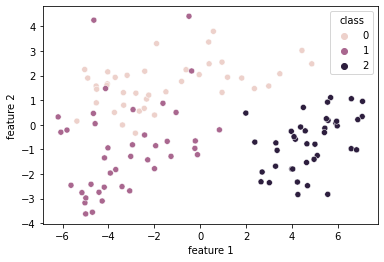

In [75]:
plot_data=pd.concat((transformed_train,y_train),axis=1)
sns.scatterplot(x="feature 1",y="feature 2",data=plot_data,hue="class")

<ul> 
<li> From the dimensionally reduced plot, we can clearly see that we can form 3 clusters from the input data.</li>
<li>Even though it's a labelled output feature problem, there's no harm in seeing how k-means clustering works out.</li>
    <li>Early Blight(1) and late blight(2) might have overlapping data-points. But for detection,we can easily separate the cluster points i.e class 2(healthy) and classes 0,1 (diseased) can be easily clustered.</li>
</ul>

<h2> Applying K-means clustering</h2>

In [77]:
model=KMeans(n_clusters=3,init='k-means++',n_init=1000,max_iter=1000,random_state=42,algorithm="full")

In [78]:
model.fit(transformed_train)
y_means=model.predict(transformed_train)

In [79]:
y_means

array([1, 0, 2, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 2, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

<h2>Visualizing clusters</h2>

In [80]:
y_means=pd.DataFrame(y_means,columns=["cluster group"])
result_df=pd.concat((X[["Autocorrelation","Contrast"]],y_means),axis=1)
result_df.head()

,Autocorrelation,Contrast,cluster group
0,4.937605,0.423813,1
1,2.551722,0.259480,0
2,6.206039,0.618669,2
3,1.885596,0.194235,0
4,4.790395,0.481035,1


<AxesSubplot:xlabel='Autocorrelation', ylabel='Contrast'>

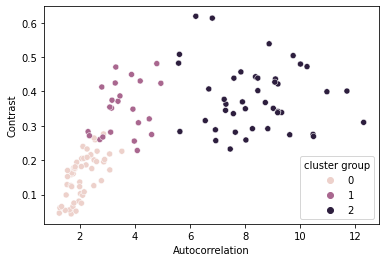

In [81]:
sns.scatterplot(x="Autocorrelation",y="Contrast",hue="cluster group",data=result_df)

<h2>Model Accuracy Test</h2>

In [82]:
test_data=pd.read_csv("./Data/test_data.csv")

In [83]:
test_data.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


In [84]:
y_test=test_data["class"]
X_test=test_data.drop(labels="class",axis=1)
X_test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,5.094305,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.641339,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,6.453880,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,1.945784,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,4.978558,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550


In [85]:
scaler=StandardScaler()
columns=X_test.columns
X_test=pd.DataFrame(scaler.fit_transform(X_test),columns=columns)

In [86]:
print(X_test.shape)
X_test.head()


(192, 22)


,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum of sqaures: Variance,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized
0,0.115955,1.152092,-0.063260,-0.063260,0.663416,1.257780,0.755880,-0.444491,0.569418,-0.598628,...,0.138458,0.159867,0.101277,0.529910,1.152092,0.854109,0.827370,0.661432,-0.698731,-1.088670
1,-0.644152,-0.067471,-0.570890,-0.570890,0.305115,0.562541,-0.506573,0.703553,-0.656922,0.618894,...,-0.635841,-0.669291,-0.590586,-0.667035,-0.067471,-0.496450,0.648385,-0.589191,0.551824,0.181128
2,0.520059,2.598176,-0.349695,-0.349695,1.389672,1.896021,1.325791,-0.652310,0.815626,-0.919408,...,0.567620,0.505509,0.598211,0.749419,2.598176,1.234232,1.437455,0.689112,-1.163883,-2.300985
3,-0.856370,-0.551674,-1.554955,-1.554955,-1.160467,-0.800335,-0.712855,0.844693,-0.837531,0.756352,...,-0.855399,-0.844815,-0.880083,-0.853280,-0.551674,-0.709546,0.964802,-0.974671,0.726473,0.573161
4,0.069056,1.576752,-0.143906,-0.143906,2.038404,2.544765,0.530200,-0.012862,0.117843,-0.199718,...,0.101922,0.003116,0.244472,0.091031,1.576752,0.530089,1.037520,0.258099,-0.401019,-1.347249


In [87]:
y_test.value_counts()

1    74
2    61
0    57
Name: class, dtype: int64

In [91]:
pca = PCA(n_components=2,copy=True)
transformed_test=pca.fit_transform(X_test)
transformed_test.shape

(192, 2)

In [92]:
predictions=model.predict(transformed_test)
print(predictions)
print(y_test)

[1 0 2 0 1 2 0 0 0 0 0 1 0 0 1 2 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 2 1 1 0 1
 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2]
0      0
1      0
2      0
3      0
4      0
      ..
187    2
188    2
189    2
190    2
191    2
Name: class, Length: 192, dtype: int64


In [93]:
def score(y_test,predictions):
    print(classification_report(y_test,predictions))
    print(pd.DataFrame(predictions).value_counts())
    print("Accuracy score ={score}".format(score=accuracy_score(y_test,predictions)))
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.35      0.54      0.42        57
           1       0.41      0.22      0.28        74
           2       0.94      0.98      0.96        61

    accuracy                           0.56       192
   macro avg       0.57      0.58      0.56       192
weighted avg       0.56      0.56      0.54       192

0    89
2    64
1    39
dtype: int64
Accuracy score =0.5572916666666666


<p>Without P.C.A accuracy is 30 percent</p>

<p>with P.C.A algorithm accuracy is 55 percent, which although is not good, but is a good increment from the original.</p>

<p> for P.C.A precision and recall for healthy is high, which means K-means might work good if only detection is concerned</p>

<h2>Confusion Matrix</h2>

In [96]:
def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.savefig(filepath,dpi=400)

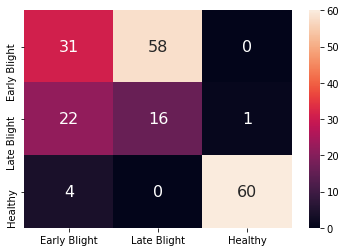

In [95]:
plot_matrix(y_test,predictions,'./images/Kmeans/ConfMatrixKmeans.png')

<p>So we can see that most late blight features were misclassified but healthy has high precision and recall</p>

<h2> ROC Curve</h2>

In [97]:
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for tomato disease classification')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=400)

0: 89
1 :39
2 :64


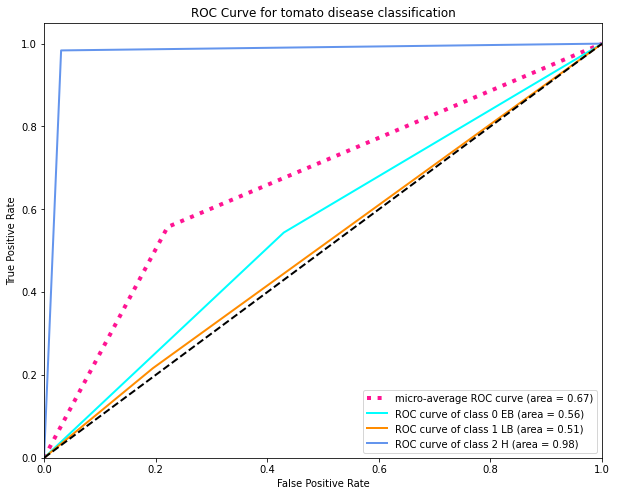

In [99]:
plot_roc(y_test,predictions,'./images/Kmeans/Roc_Kmeans.png')